# Quickstart: Solar Spectral

In this notebook, we'll run a spectral solar simulation — computing wavelength-resolved irradiance over a full day at a fixed location. This is one of the most common pyRadtran use cases: understanding how solar radiation varies spectrally and temporally.

In [1]:
import pyradtran  # Registers the .pyradtran xarray accessor
from pyradtran import load_config
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
from matplotlib import cm
import logging

# Suppress verbose solver output
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

# ── Simulation parameters ─────────────────────────────────────────────────────
# Load merged defaults + master config (~/.pyradtran/config.yaml), then customise
cfg = load_config()

# Spectral solar — no wavelength integration (retain full spectrum)
cfg.simulation_defaults.rte_solver           = "disort"
cfg.simulation_defaults.mol_abs_param        = "lowtran per_nm"
cfg.simulation_defaults.source               = "solar"
cfg.simulation_defaults.wavelength_nm        = [400, 700]
cfg.simulation_defaults.integrate_wavelength = False

# Output at all altitudes
cfg.simulation_defaults.output_columns       = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo"]
cfg.execution.cleanup_temp_files = False

config_path = Path("config/spectral_config.yaml")
cfg.to_yaml(config_path)
print(f"Config saved to {config_path}")

# ── Input dataset ─────────────────────────────────────────────────────────────
# Stationary at fixed location, stepping through time
N_timesteps = 10

ds = xr.Dataset(
    coords={
        'time'      : pd.date_range('2025-04-04T08:00:00', periods=N_timesteps, freq='h'),
        'latitude'  : ('time', [61.0] * N_timesteps),
        'longitude' : ('time', [22.0] * N_timesteps),
        'altitude'  : ('altitude', [0, 1, 5, 10, 25, 50, 100]),
    }
)

# ── Run ───────────────────────────────────────────────────────────────────────
ds_sim = ds.pyradtran.run(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    show_progress=False,
)

print("\nSimulation complete!")
print(f"Dataset variables: {list(ds_sim.data_vars.keys())}")
print(f"Dataset coordinates: {list(ds_sim.coords.keys())}")
print(f"Dataset dimensions: {dict(ds_sim.dims)}")

2026-04-19 01:27:01,148 - pyradtran.config - INFO - Configuration written to config/spectral_config.yaml


Config saved to config/spectral_config.yaml

Simulation complete!
Dataset variables: ['zout', 'lambda', 'sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']
Dataset coordinates: ['time', 'wavelength', 'altitude']
Dataset dimensions: {'time': 10, 'wavelength': 301, 'altitude': 7}


/tmp/ipykernel_17405/3102401704.py:57: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dataset dimensions: {dict(ds_sim.dims)}")


## Explore the Output Dataset

The simulation returns an `xr.Dataset` with irradiance fields indexed by `time`, `altitude`, and `wavelength`.

In [2]:
ds_sim

<xarray.Dataset> Size: 2MB
Dimensions:     (time: 10, wavelength: 301, altitude: 7)
Coordinates:
  * time        (time) datetime64[ns] 80B 2025-04-04T08:00:00 ... 2025-04-04T...
  * wavelength  (wavelength) float64 2kB 400.0 401.0 402.0 ... 698.0 699.0 700.0
  * altitude    (altitude) float64 56B 0.0 1.0 5.0 10.0 25.0 50.0 100.0
Data variables:
    zout        (wavelength, altitude, time) float64 169kB 0.0 0.0 ... 100.0
    lambda      (wavelength, altitude, time) float64 169kB 400.0 400.0 ... 700.0
    sza         (wavelength, altitude, time) float64 169kB 62.63 58.42 ... 88.83
    edir        (wavelength, altitude, time) float64 169kB 362.5 454.4 ... 28.84
    eglo        (wavelength, altitude, time) float64 169kB 712.6 840.1 ... 28.84
    edn         (wavelength, altitude, time) float64 169kB 350.1 ... 8.385e-06
    eup         (wavelength, altitude, time) float64 169kB 605.7 714.1 ... 15.8
    enet        (wavelength, altitude, time) float64 169kB 106.9 126.0 ... 13.04
    albedo      (wavelength, altitude, time) float64 169kB 0.85 0.85 ... 0.5479
Attributes: (12/24)
    point_id:                      20250404_080000_61.00_22.00_0
    time:                          2025-04-04T08:00:00
    latitude:                      61.0
    longitude:                     22.0
    generated_by:                  pyradtran
    pyradtran_version:             unified_system
    ...                            ...
    config_integrate_wavelength:   0
    config_output_altitudes_km:    [0.0, 1.0, 5.0, 10.0, 25.0, 50.0, 100.0]
    config_libradtran_bin:         /opt/libRadtran-2.0.6/bin/uvspec
    config_libradtran_data:        /opt/libRadtran-2.0.6/data
    config_max_workers:            4
    config_timeout_seconds:        300

## Broadband Irradiance: Altitude × Time

We integrate the spectral irradiance over wavelength to get the broadband direct irradiance, then visualise it as a surface over altitude and time of day.

/tmp/ipykernel_17405/945561024.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


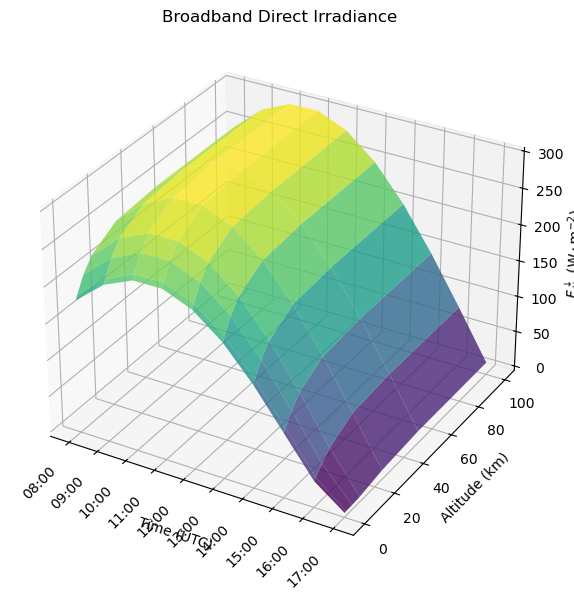

In [3]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': '3d'})

ax.set_prop_cycle(
    color=cm.viridis(np.linspace(0, 1, len(ds_sim['time'].values))),
)

# Integrate over wavelength to get broadband direct irradiance
x = np.arange(len(ds_sim['time'].values))
y = ds_sim['altitude'].values
z = ds_sim.integrate('wavelength')['edir'].values / 1000
X, Y = np.meshgrid(x, y)

ax.plot_surface(X, Y, z, cmap=cm.viridis, edgecolor='none', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(ds_sim['time'].dt.strftime('%H:%M').values, rotation=45, ha='right')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Altitude (km)')
ax.set_zlabel(r'$F_\mathrm{dir}^\downarrow$ ($\mathrm{W \cdot m^{-2}}$)')
ax.set_title('Broadband Direct Irradiance')

plt.tight_layout()

The surface shows a clear peak at local solar noon and increases with altitude as less atmosphere lies above the observer. These are expected behaviours for clear-sky broadband irradiance.

## Spectral Direct Irradiance at the Surface

A 3-D surface showing how the spectral distribution of direct irradiance at the surface evolves over the course of the day.

Text(0.5, 0.92, 'Spectral Direct Irradiance at the Surface')

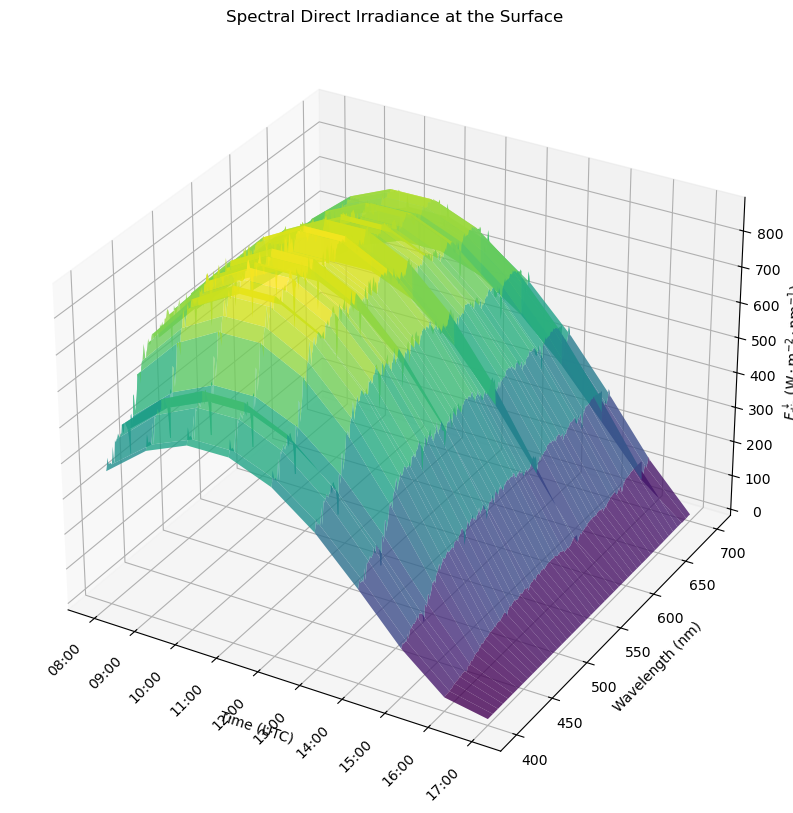

In [14]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.set_prop_cycle(
    color=cm.viridis(np.linspace(0, 1, len(ds_sim['wavelength'].values))),
)

x = np.arange(len(ds_sim['time'].values))
y = ds_sim['wavelength'].values
z = ds_sim.sel(altitude=0)['edir'].values.T
X, Y = np.meshgrid(x, y)

ax.plot_surface(X, Y, z.T, cmap=cm.viridis, edgecolor='none', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(ds_sim['time'].dt.strftime('%H:%M').values, rotation=45, ha='right')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Wavelength (nm)')
ax.set_zlabel(r'$F_\mathrm{dir}^\downarrow$ ($\mathrm{W \cdot m^{-2} \cdot nm^{-1}}$)')
ax.set_title('Spectral Direct Irradiance at the Surface')


## Spectral Irradiance Components at a Single Time Step

At a single altitude and time, we can decompose the irradiance into its direct, diffuse downward, total downward (global), and upward components. This reveals which wavelengths carry the most energy and where atmospheric absorption features appear.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

sel = ds_sim.sel(altitude=0, time='2025-04-04T12:00:00')

sel['eglo'].plot(ax=ax, label='Global (direct + diffuse)')
sel['eup'].plot(ax=ax, label='Upward')
sel['edir'].plot(ax=ax, label='Direct')
sel['edn'].plot(ax=ax, label='Diffuse downward')

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'Spectral irradiance ($\mathrm{W \cdot m^{-2} \cdot nm^{-1}}$)')
ax.set_title('Irradiance Components at 0 km, 12:00 UTC, 2025-04-04')

ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(frameon=False, loc='upper right', fontsize='small')

plt.tight_layout()

## Interpretation

- **Direct irradiance** dominates at visible wavelengths under clear-sky conditions, peaking around 450–550 nm.
- **Diffuse downward irradiance** is relatively small compared to the direct component at solar noon, but grows in proportion at shorter wavelengths due to Rayleigh scattering.
- The **absorption dips** (e.g., near 690 nm and 720 nm) correspond to O₂ and H₂O absorption bands in the atmosphere.
- **Upward irradiance** at the surface is governed by surface albedo and is much smaller than the downward components.

For integrated (broadband) simulations, see the *Solar Integrated* quickstart notebook.